In [1]:
import sys
sys.path.insert(0, "src")
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt
from kai.models.ssc import GRBShock, SSCModel

In [2]:
# Reproduce your GRB 190829A-era test case


shock_night1 = GRBShock(
    eiso      = 2e50,        # erg — from GBM
    density   = 1.0,         # cm^-3 — ISM
    tstart    = 15600,       # s
    tstop     = 28500,       # s
    redshift  = 0.0785,
    scenario  = 'ISM',
)

params_night1 = {
    'log10_eta_e':  -0.04,    # eta_e ~ 0.91
    'log10_ebreak': -1.513,   # E_break ~ 0.031 TeV
    'alpha2':        3.15,
    'log10_ecut':    1.7,     # E_cut ~ 50 TeV
    'log10_B':      -0.448,   # B ~ 0.36 G
}

In [3]:
shock_night2 = GRBShock(
    eiso      = 2e50,
    density   = 1.0,
    tstart    = 97900,
    tstop     = 115000,
    redshift  = 0.0785,
    scenario  = 'ISM',
)

params_night2 = {
    'log10_eta_e':  -0.04,
    'log10_ebreak': -1.31,
    'alpha2':        3.06,
    'log10_ecut':    1.6,
    'log10_B':      -0.77,
}

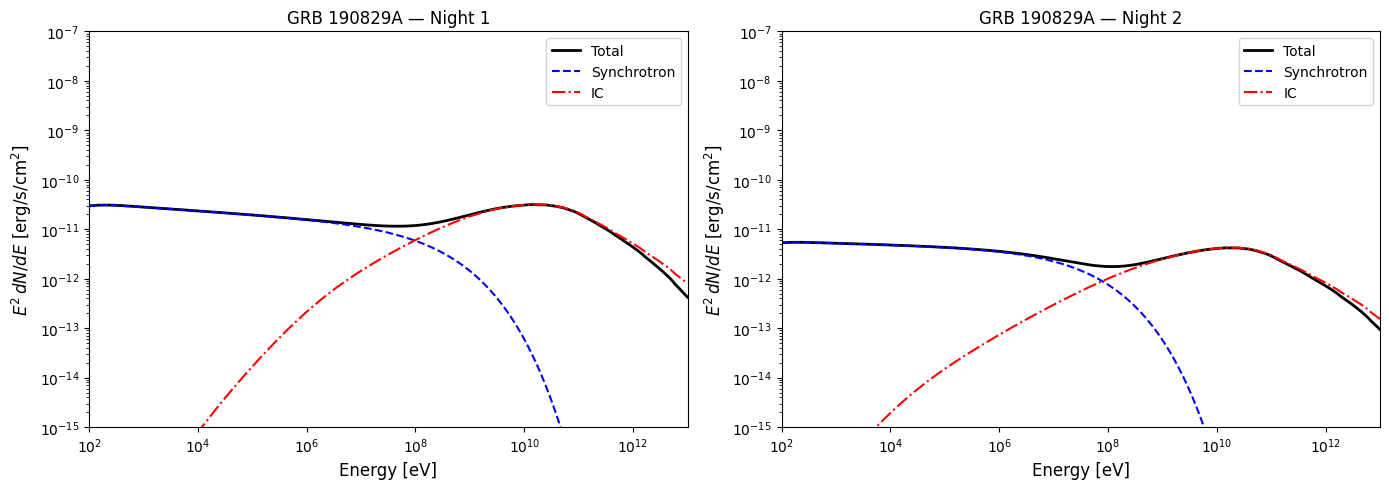

In [13]:
energy = np.logspace(2, 13, 200) * u.eV   # 100 eV to 10 TeV

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (shock, params, label) in zip(axes, [
    (shock_night1, params_night1, "Night 1"),
    (shock_night2, params_night2, "Night 2"),
]):
    model = SSCModel(shock, absorption_method=2)
    sed   = model.sed(energy, params)

    ax.loglog(energy, sed,               'k-',  lw=2,   label='Total')
    ax.loglog(energy, model.synch_comp,  'b--', lw=1.5, label='Synchrotron')
    ax.loglog(energy, model.ic_comp,     'r-.', lw=1.5, label='IC')
    ax.set_xlabel("Energy [eV]", fontsize=12)
    ax.set_ylabel(r"$E^2\,dN/dE$ [erg/s/cm$^2$]", fontsize=12)
    ax.set_title(f"GRB 190829A — {label}")
    ax.set_xlim(1e2, 1.0e13)
    ax.set_ylim(1e-15, 1e-7)
    ax.legend()

plt.tight_layout()
plt.savefig("grb190829a_validation.png", dpi=150)
plt.show()

In [3]:
shock_night1.summary()

GRBShock (ISM)
  Eiso         = 2.00e+55 erg
  density      = 1.700e+00 cm^-3
  t_obs        = 195000.0 s
  Gamma        = 8.09
  R            = 3.057e+18 cm
  E_shock/vol  = 3.341e-01 erg/cm^3
  redshift     = 0.151
  D_L          = 726.515 Mpc


In [4]:
model1 = SSCModel(shock_night1)
energy = np.logspace(3, 13, 100) * u.eV

In [5]:
sed1 = model1.sed(energy, params_night1)
model1.summary()
print(f"SED shape: {sed1.shape}")
print(f"SED range: {sed1.min():.3e} -- {sed1.max():.3e}")

SSCModel
  Absorption method : 2
GRBShock (ISM)
  Eiso         = 2.00e+55 erg
  density      = 1.700e+00 cm^-3
  t_obs        = 195000.0 s
  Gamma        = 8.09
  R            = 3.057e+18 cm
  E_shock/vol  = 3.341e-01 erg/cm^3
  redshift     = 0.151
  D_L          = 726.515 Mpc
  Emin             = 2.467e+04 eV
  eta_e            = 0.0009
  eta_b            = 1.6438e-01
SED shape: (100,)
SED range: 3.356e-11 erg / (s cm2) -- 3.967e-05 erg / (s cm2)


SSCModel
  Absorption method : 2
GRBShock (ISM)
  Eiso         = 2.00e+55 erg
  density      = 1.700e+00 cm^-3
  t_obs        = 195000.0 s
  Gamma        = 8.09
  R            = 3.057e+18 cm
  E_shock/vol  = 3.341e-01 erg/cm^3
  redshift     = 0.151
  D_L          = 726.515 Mpc
  Emin             = 2.467e+04 eV
  eta_e            = 0.0009
  eta_b            = 1.6438e-01

SED shape : (100,)
SED max   : 3.967e-05 erg / (s cm2)
SED min   : 3.356e-11 erg / (s cm2)


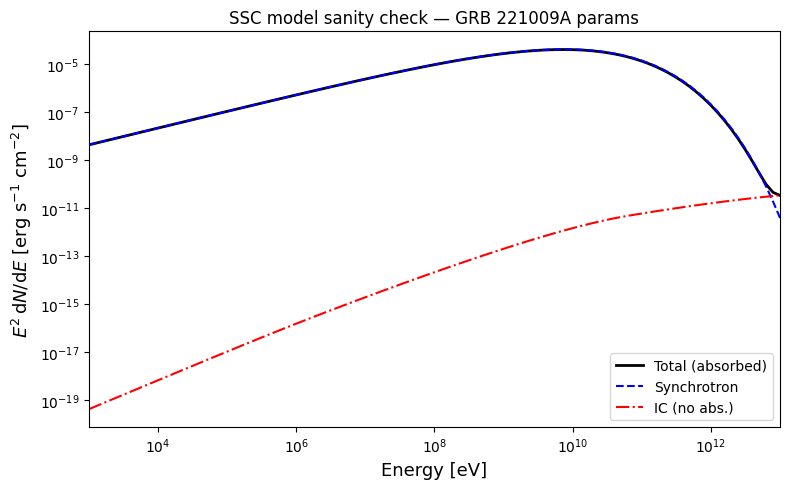

In [6]:
model1.summary()
print(f"\nSED shape : {sed.shape}")
print(f"SED max   : {sed.max():.3e}")
print(f"SED min   : {sed[sed>0].min():.3e}")

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(energy, sed,              'k-',  lw=2,       label='Total (absorbed)')
ax.loglog(energy, model.synch_comp, 'b--', lw=1.5,     label='Synchrotron')
ax.loglog(energy, model.ic_comp,    'r-.', lw=1.5,     label='IC (no abs.)')
ax.set_xlabel("Energy [eV]", fontsize=13)
ax.set_ylabel(r"$E^2\,\mathrm{d}N/\mathrm{d}E$ [erg s$^{-1}$ cm$^{-2}$]", fontsize=13)
ax.set_title("SSC model sanity check — GRB 221009A params")
ax.set_xlim(1e3, 1e13)
ax.legend()
plt.tight_layout()
plt.savefig("ssc_sanity_check.png", dpi=150)
plt.show()